# Travail sur le nouveau dataset

Dataset récupéré par scraping de https://www.classicals.de/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
import seaborn as sns
from sklearn.decomposition import PCA
from collections import Counter
import umap.umap_ as umap
import plotly.express as px
import plotly.io as pio
from preprocessing import BulkPreprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [18]:
def periode(str):
    try:
        chain = str.split("(")[1]
        date_deb = int(chain[0:4])
        if date_deb is None :
            return "Unknown"
        elif date_deb == 0:
            return "Traditionnel"
        elif date_deb < 1570 and date_deb > 476:
            return "Medieval"
        elif date_deb < 1730:
            return "Baroque"
        elif date_deb < 1800:
            return "Classique"
        elif date_deb < 1860:
            return "Romantique"
        else:
            return "XXe"
    except :
        return "Unknown"

In [14]:
periode("Jacques Offenbach (1819-1880)")

1819-1880)


'Romantique'

In [2]:
pio.renderers.default = 'notebook_connected' #ou 'notebook_connected' ou 'iframe' ou 'svg' ou 'png' 

## Pour jouer sur le pre-processing

In [34]:
picklefile = "data_classicalsde_N=5.pkl"
picklefile2 = "data_musicmasterpieces.pkl"
audio_dir = "audiofiles/classicalsde_csv"
audio_dir2 = "audiofiles/100ClassicalMusicMasterpieces_csv"
loudness_resolution = 50
overlap = 0.5
N = 5

bulk_preprocessing = BulkPreprocessing(picklefile, picklefile2, audio_dir, audio_dir2, loudness_resolution, overlap, N)
bulk_preprocessing.pickle_dump_classicalsde()

Compositeur : Dionisio Aguado (1784 - 1849)
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - 8 Lessons for the Guitar - No. 2 in A minor.csv
Informations : Aguado,Dionisio,1784,1849, Default
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - Andantino in A minor - Nuevo metodo para guitarra, Leccion 19.csv
Informations : Aguado,Dionisio,1784,1849, Default
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - Arpeggio Study No. 6 in E minor.csv
Informations : Aguado,Dionisio,1784,1849, Default
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - Guitar Study - Etude No. 15 - Guitar Etudes.csv
Informations : Aguado,Dionisio,1784,1849, Default
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - Guitar Study - Etude No. 27 - Guitar E

## Visualisation du dataset

In [40]:
N=5
with open(f"data_classicalsde_N={N}.pkl", "rb") as f:
    dico_cross_era_sup, grouping_dict, compo_dict = pickle.load(f)

li_outliers = ['Rossini', 'Necke', 'Mascagni']
X = []
etiquettes = []
per = []
y = []
groupe = []
for file, histograms in dico_cross_era_sup.items():
    composer = compo_dict[file]
    if any(outlier in composer for outlier in li_outliers):
        continue
    else:
        etiquettes.append(file.split("\\")[-2] + '\\' + file.split('\\')[-1])
        matrice = np.vstack(histograms)
        X.append(matrice.flatten())
        y.append(composer)
        per.append(periode(composer))
        groupe.append(grouping_dict[file][1])

X = np.array(X)
# print(f"Shape de X : {X.shape}")
# print(f"Shape de y : {len(y)}")
# print(f"Nombre de compositeurs : {len(set(y))}")
# print(f"Shape de groupe : {len(groupe)}")
# print("Comptage des classes :", pd.Series(y).value_counts())
# print(f"X : {X}")

y = np.array(y)
periodes = np.array(groupe)
morceaux = np.array(etiquettes)
per2 = np.array(per)

#X_scaled = StandardScaler().fit_transform(X)
X_scaled = X

compteur = Counter(y)
indices_a_garder = [i for i, label in enumerate(y) if compteur[label] > 1 or "Traditional" not in label]

X2 = X_scaled[indices_a_garder]
y2 = y[indices_a_garder]
groupe = [groupe[i] for i in indices_a_garder]
etiquettes = [etiquettes[i] for i in indices_a_garder]

reducer = LDA(n_components=3)
reducer.fit(X2,y2)
X_lda = reducer.transform(X_scaled)
#print(f"X_lda : {X_lda}")

df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2', 'LD3'])
df_lda['composer'] = y
df_lda['morceau'] = morceaux
df_lda['groupe'] = periodes

fig = px.scatter_3d(
    df_lda,
    x='LD1', y='LD2', z='LD3',
    color='composer',
    hover_data={'morceau': True, 'composer': True, 'groupe': True},
    title=f'Projection par LDA des morceaux avec N={N}'
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_traces(marker=dict(size=4))
buttons = [
    dict(label='Tout masquer',
        method='restyle',
        args=['visible', ['legendonly'] * len(fig.data)]),
    
    dict(label='Tout afficher',
        method='restyle',
        args=['visible', [True] * len(fig.data)])
]

fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=True, buttons=buttons)]
)

fig.show(renderer= 'browser')

In [42]:
# Calculer les centroïdes pour chaque compositeur
# On retire la colonne 'periode' avant de faire la moyenne
df_X = pd.DataFrame(X_lda)
df_X['composer'] = y
centroides = df_X.groupby('composer').mean()
df_X['periode'] = per2

periode_centroide = df_X.groupby('composer')['periode'].agg(lambda x: x.value_counts().idxmax())
# Supprimer Richard Strauss des centroïdes et des périodes associées
centroides = centroides.drop('Richard Strauss (1864 - 1949)', errors='ignore')
periode_centroide = periode_centroide.drop('Richard Strauss (1864 - 1949)', errors='ignore')
centroides_pca = centroides.values

fig = px.scatter_3d(
    x=centroides_pca[:, 0],
    y=centroides_pca[:, 1],
    z=centroides_pca[:, 2],
    # text=centroides.index,
    hover_name=centroides.index,
    color=periode_centroide,
    title="Centroïdes des compositeurs après UMAP",
    labels={'x': 'LDA1', 'y': 'LDA2', 'z': 'LDA3', 'color': 'Période'}
)
fig.update_traces(marker=dict(size=8))
fig.show(renderer = 'browser')

## Robustesse du modèle par-rapport aux influences extérieures

In [26]:
with open("data_classicalsde_N=5.pkl", "rb") as f:
    dico_cross_era_sup, grouping_dict, compo_dict = pickle.load(f)

li_outliers = ['Rossini', 'Necke', 'Mascagni']
X = []
etiquettes = []
y = []
groupe = []
for file, histograms in dico_cross_era_sup.items():
    composer = compo_dict[file]
    if any(outlier in composer for outlier in li_outliers):
        continue
    else:
        etiquettes.append(file.split("\\")[-2] + '\\' + file.split('\\')[-1])
        matrice = np.vstack(histograms)
        X.append(matrice.flatten())
        y.append(composer)
        groupe.append(grouping_dict[file][1])

X = np.array(X)

y = np.array(y)
y_num = LabelEncoder().fit_transform(y)
#print(y)
periodes = np.array(groupe)
morceaux = np.array(etiquettes)

X_scaled = StandardScaler().fit_transform(X)

compteur = Counter(y)
indices_a_garder = [i for i, label in enumerate(y) if compteur[label] > 1 or 'Traditional' not in label]

X2 = X_scaled[indices_a_garder]
y2 = y_num[indices_a_garder]

reducer = umap.UMAP(n_components=3, random_state=42, metric = "cosine", n_neighbors=15, min_dist=0.1, verbose=True, densmap = False, 
                    target_metric = 'categorical', target_weight = 0.7)
reducer.fit(X2, y = y2)
X_umap = reducer.transform(X_scaled)
#print(f"X_umap : {X_umap}")

df_umap = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_umap['composer'] = y
df_umap['morceau'] = morceaux
df_umap['groupe'] = periodes

fig = px.scatter_3d(
    df_umap,
    x='UMAP1', y='UMAP2', z='UMAP3',
    color='composer',
    hover_data={'morceau': True, 'composer': True, 'groupe': True},
    title=f'Projection UMAP 3D des morceaux avec N={N}'
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_traces(marker=dict(size=4))
buttons = [
    dict(label='Tout masquer',
        method='restyle',
        args=['visible', ['legendonly'] * len(fig.data)]),
    
    dict(label='Tout afficher',
        method='restyle',
        args=['visible', [True] * len(fig.data)])
]

fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=True, buttons=buttons)]
)
fig.show(renderer = 'browser')

UMAP(angular_rp_forest=True, metric='cosine', n_components=3, n_jobs=1, random_state=42, target_weight=0.7, verbose=True)
Mon Jun  2 00:00:14 2025 Construct fuzzy simplicial set
Mon Jun  2 00:00:27 2025 Finding Nearest Neighbors
Mon Jun  2 00:00:27 2025 Finished Nearest Neighbor Search
Mon Jun  2 00:00:27 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Jun  2 00:00:29 2025 Finished embedding


In [27]:
y2_cat = y[indices_a_garder]
unique_composers = np.unique(y2_cat)
centroids = []
labels = []

for composer in unique_composers:
    indices = np.where(y2_cat == composer)[0]
    centroid = reducer.embedding_[indices].mean(axis=0)
    centroids.append(centroid)
    labels.append(composer)

centroids = np.array(centroids)

df_centroids = pd.DataFrame(centroids, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_centroids['composer'] = labels

fig = px.scatter_3d(
    df_centroids,
    x='UMAP1', y='UMAP2', z='UMAP3',
    color='composer',
    hover_data={'composer': True},
    title='Projection UMAP 3D des centroïdes par compositeur'
)
fig.update_traces(marker=dict(size=8, opacity=0.9))
fig.show(renderer='browser')

## Entraînement d'un SVM

In [30]:
from sklearn.svm import SVC

kernel = 'linear'
dim_pca = 6

with open("data_classicalsde_N=5.pkl", "rb") as f:
    dico_cross_era_sup, grouping_dict, compo_dict = pickle.load(f)

li_outliers = ['Rossini', 'Necke', 'Mascagni']
X = []
etiquettes = []
y = []
groupe = []
for file, histograms in dico_cross_era_sup.items():
    composer = compo_dict[file]
    if any(outlier in composer for outlier in li_outliers):
        continue
    else:
        etiquettes.append(file.split("\\")[-2] + '\\' + file.split('\\')[-1])
        matrice = np.vstack(histograms)
        X.append(matrice.flatten())
        y.append(composer)
        groupe.append(grouping_dict[file][1])

X = np.array(X)
# print(f"Shape de X : {X.shape}")
# print(f"Shape de y : {len(y)}")
# print(f"Nombre de compositeurs : {len(set(y))}")
# print(f"Shape de groupe : {len(groupe)}")
# print("Comptage des classes :", pd.Series(y).value_counts())
# print(f"X : {X}")

y = np.array(y)
periodes = np.array(groupe)
morceaux = np.array(etiquettes)

#X_scaled = StandardScaler().fit_transform(X)
X_scaled = X

y_num = LabelEncoder().fit_transform(y)

reducer = PCA(n_components=dim_pca, random_state=42)
X_scaled = reducer.fit_transform(X_scaled, y_num)

print("PCA faite")

svm = SVC(kernel=kernel, probability=True)
svm.fit(X_scaled, y)

print("SVM entraîné")

lda = LDA(n_components=3)
X_lda = lda.fit_transform(X_scaled, y)

print("LDA faite")

y_pred = svm.predict(X_scaled)
#print(y_pred)

print("Prédictions faites")


df_visu = pd.DataFrame(X_lda, columns=['LD1', 'LD2', 'LD3'])
df_visu['composer'] = y
df_visu['pred'] = y_pred

fig = px.scatter_3d(
    df_visu,
    x='LD1', y='LD2', z='LD3',
    color='composer',
    symbol='pred',
    title='Résultats du SVM'
)
buttons = [
    dict(label='Tout masquer',
        method='restyle',
        args=['visible', ['legendonly'] * len(fig.data)]),
    
    dict(label='Tout afficher',
        method='restyle',
        args=['visible', [True] * len(fig.data)])
]

fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=True, buttons=buttons)]
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.show(renderer='browser')

PCA faite
SVM entraîné
LDA faite
Prédictions faites


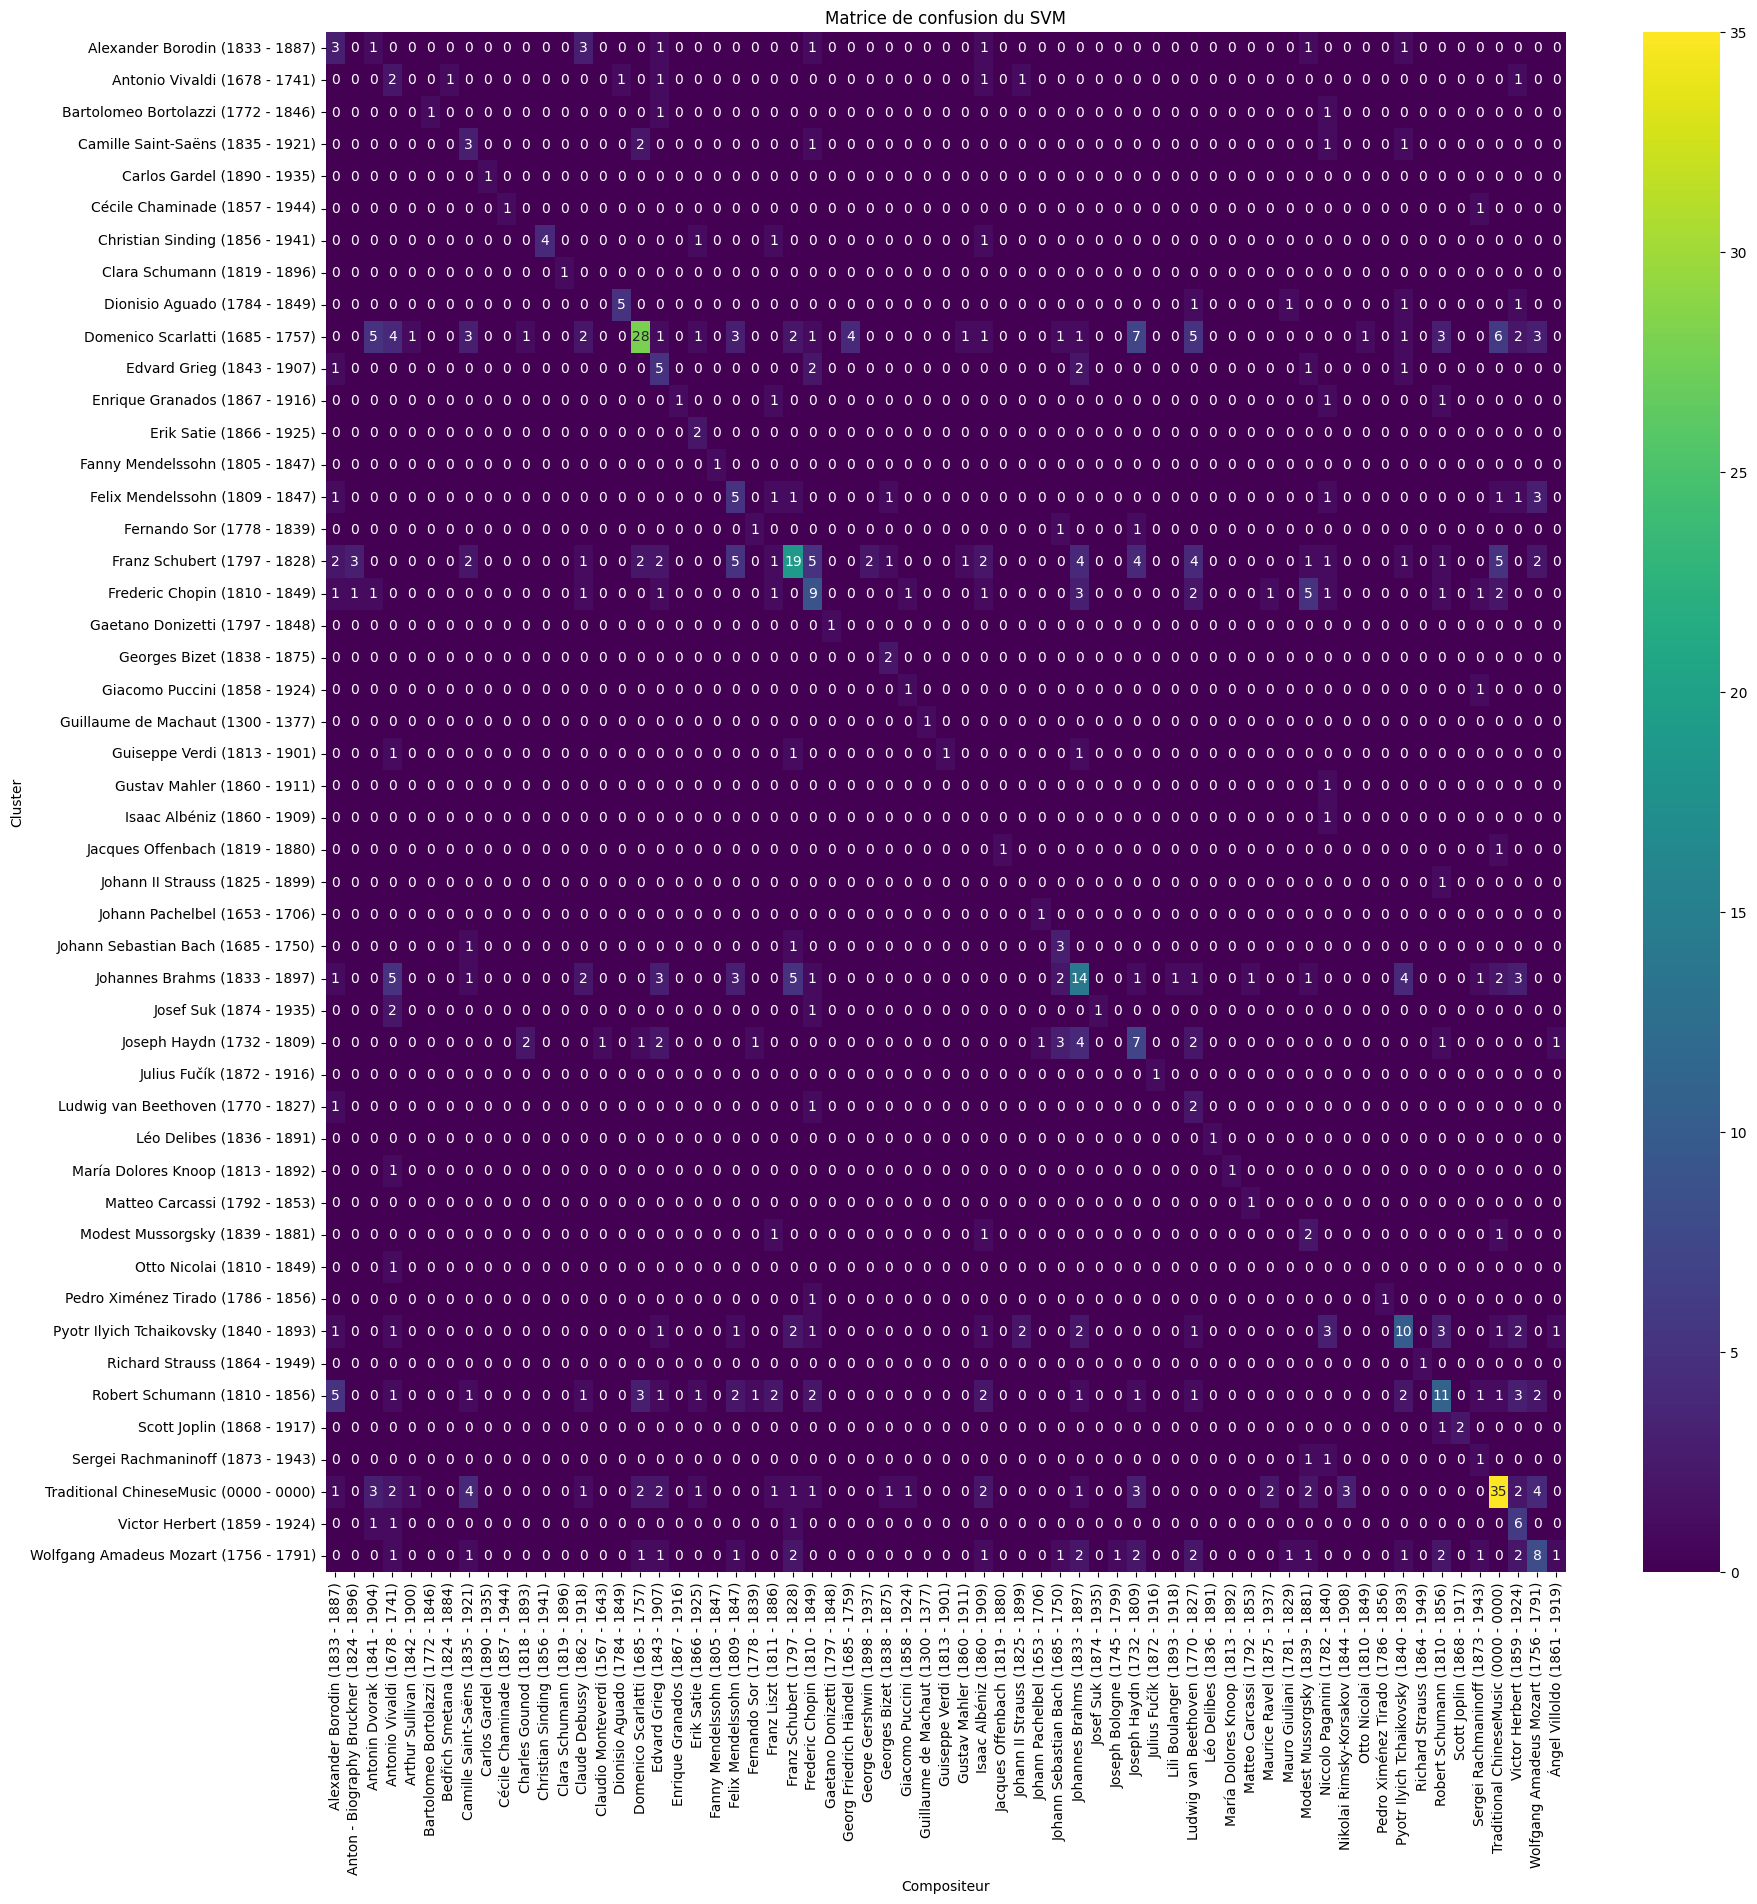

In [31]:
df_cm = pd.crosstab(y_pred, y)

plt.figure(figsize=(20, 20))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='viridis')
plt.xlabel('Compositeur')
plt.ylabel('Cluster')
plt.title('Matrice de confusion du SVM')
plt.show()

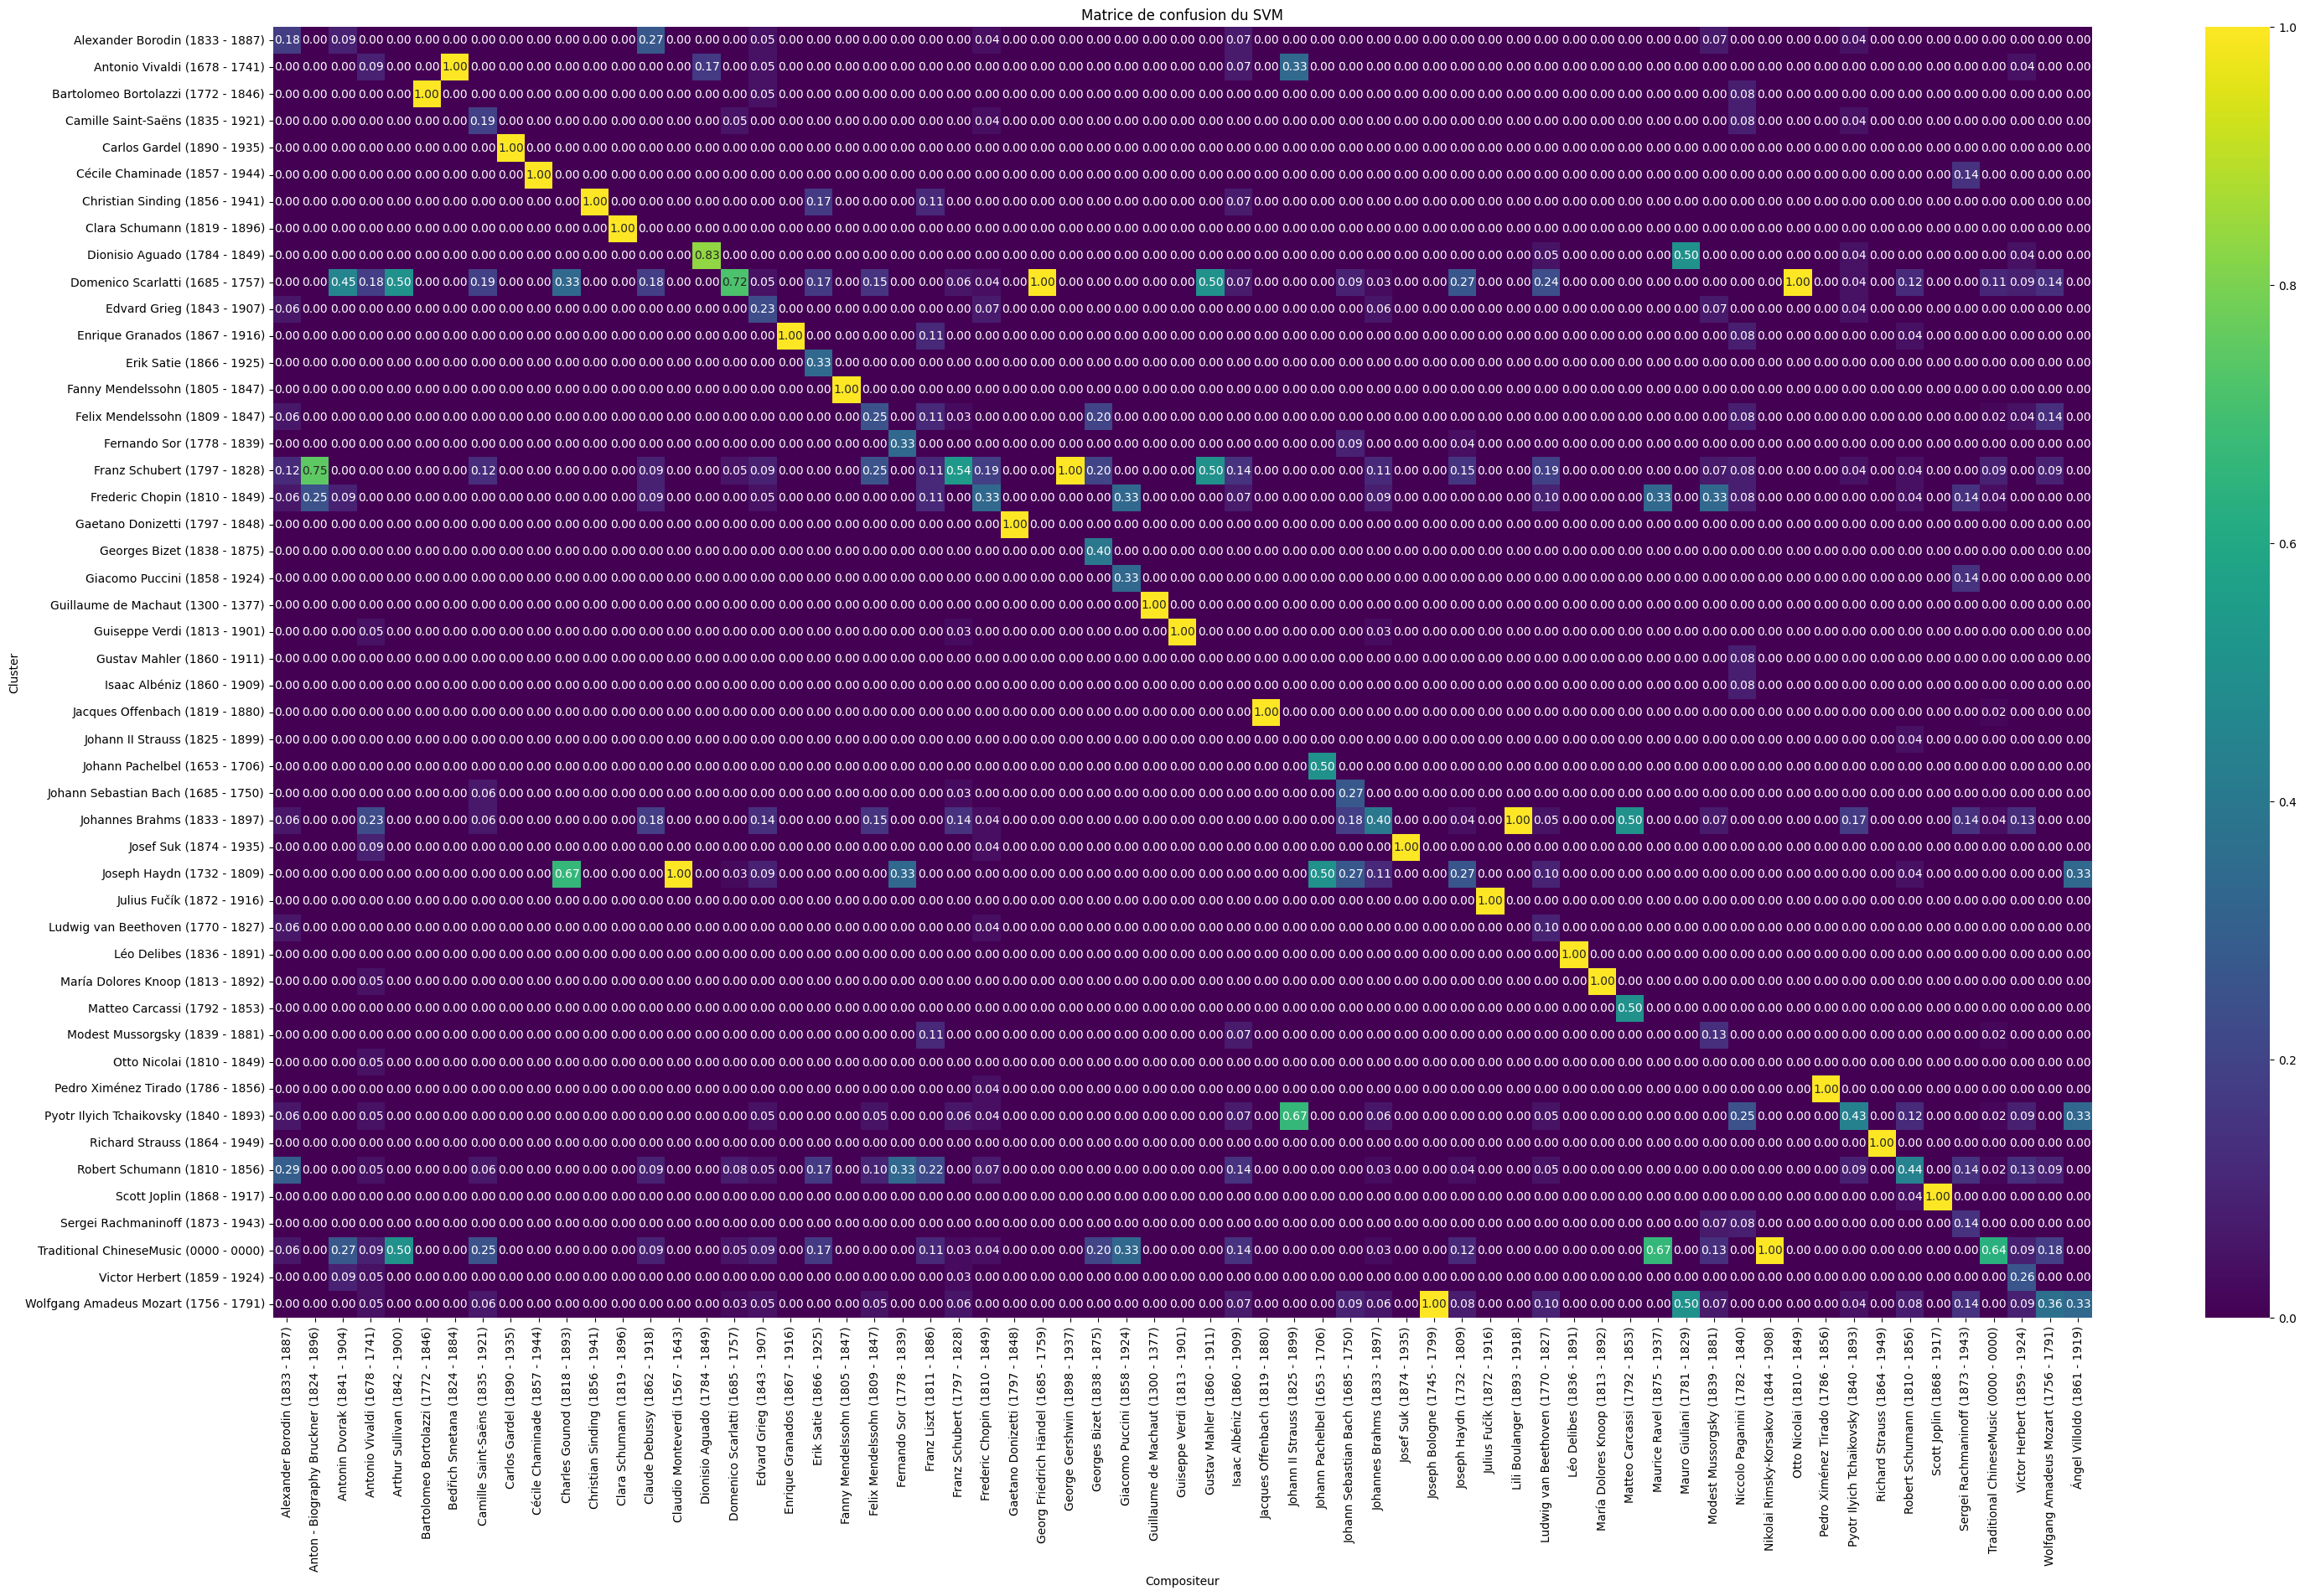

In [32]:
df_cm = pd.crosstab(y_pred, y)
df_cm = df_cm.div(df_cm.sum(axis=0), axis=1)
plt.figure(figsize=(35, 20))
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap='viridis')
plt.xlabel('Compositeur')
plt.ylabel('Cluster')
plt.title('Matrice de confusion du SVM')
plt.show()

## Tests d'efficacité

In [ ]:
from sklearn.svm import SVC

kernel = 'linear'
dim_pca = 20

with open("data_classicalsde_N=5.pkl", "rb") as f:
    dico_cross_era_sup, grouping_dict, compo_dict = pickle.load(f)

li_outliers = ['Rossini', 'Necke', 'Mascagni', "Traditional"]
X = []
etiquettes = []
y = []
groupe = []
for file, histograms in dico_cross_era_sup.items():
    composer = compo_dict[file]
    if any(outlier in composer for outlier in li_outliers):
        continue
    else:
        etiquettes.append(file.split("\\")[-2] + '\\' + file.split('\\')[-1])
        matrice = np.vstack(histograms)
        X.append(matrice.flatten())
        y.append(composer)
        groupe.append(grouping_dict[file][1])

X = np.array(X)
y = np.array(y)
periodes = np.array(groupe)
morceaux = np.array(etiquettes)

compteur = Counter(y)
indices_a_garder = [i for i, label in enumerate(y) if compteur[label] > 1 and 'Traditional' not in label]

X = X[indices_a_garder]
y = y[indices_a_garder]

X_scaled = StandardScaler().fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

reducer = LDA(n_components=dim_pca)
reducer.fit(X_train, y_train)
X_train_pca = reducer.transform(X_train)
X_test_pca = reducer.transform(X_test)

print("PCA faite")

svm = SVC(kernel=kernel, probability=True)
svm.fit(X_train_pca, y_train)
y_train_pred = svm.predict(X_train_pca)
y_test_pred = svm.predict(X_test_pca)

print("SVM entraîné")

lda = LDA(n_components=3)
X_train_lda = lda.fit_transform(X_train_pca, y_train)
X_test_lda = lda.transform(X_test_pca)

print("LDA faite")

df_visu = pd.DataFrame(X_test_lda, columns=['LD1', 'LD2', 'LD3'])
df_visu['composer'] = y_test
df_visu['pred'] = y_test_pred

fig = px.scatter_3d(
    df_visu,
    x='LD1', y='LD2', z='LD3',
    color='composer',
    symbol='pred',
    title="Résultats du SVM sur l'ensemble de test"
)
buttons = [
    dict(label='Tout masquer',
        method='restyle',
        args=['visible', ['legendonly'] * len(fig.data)]),
    
    dict(label='Tout afficher',
        method='restyle',
        args=['visible', [True] * len(fig.data)])
]

fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=True, buttons=buttons)]
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.show(renderer='browser')

PCA faite
SVM entraîné
LDA faite


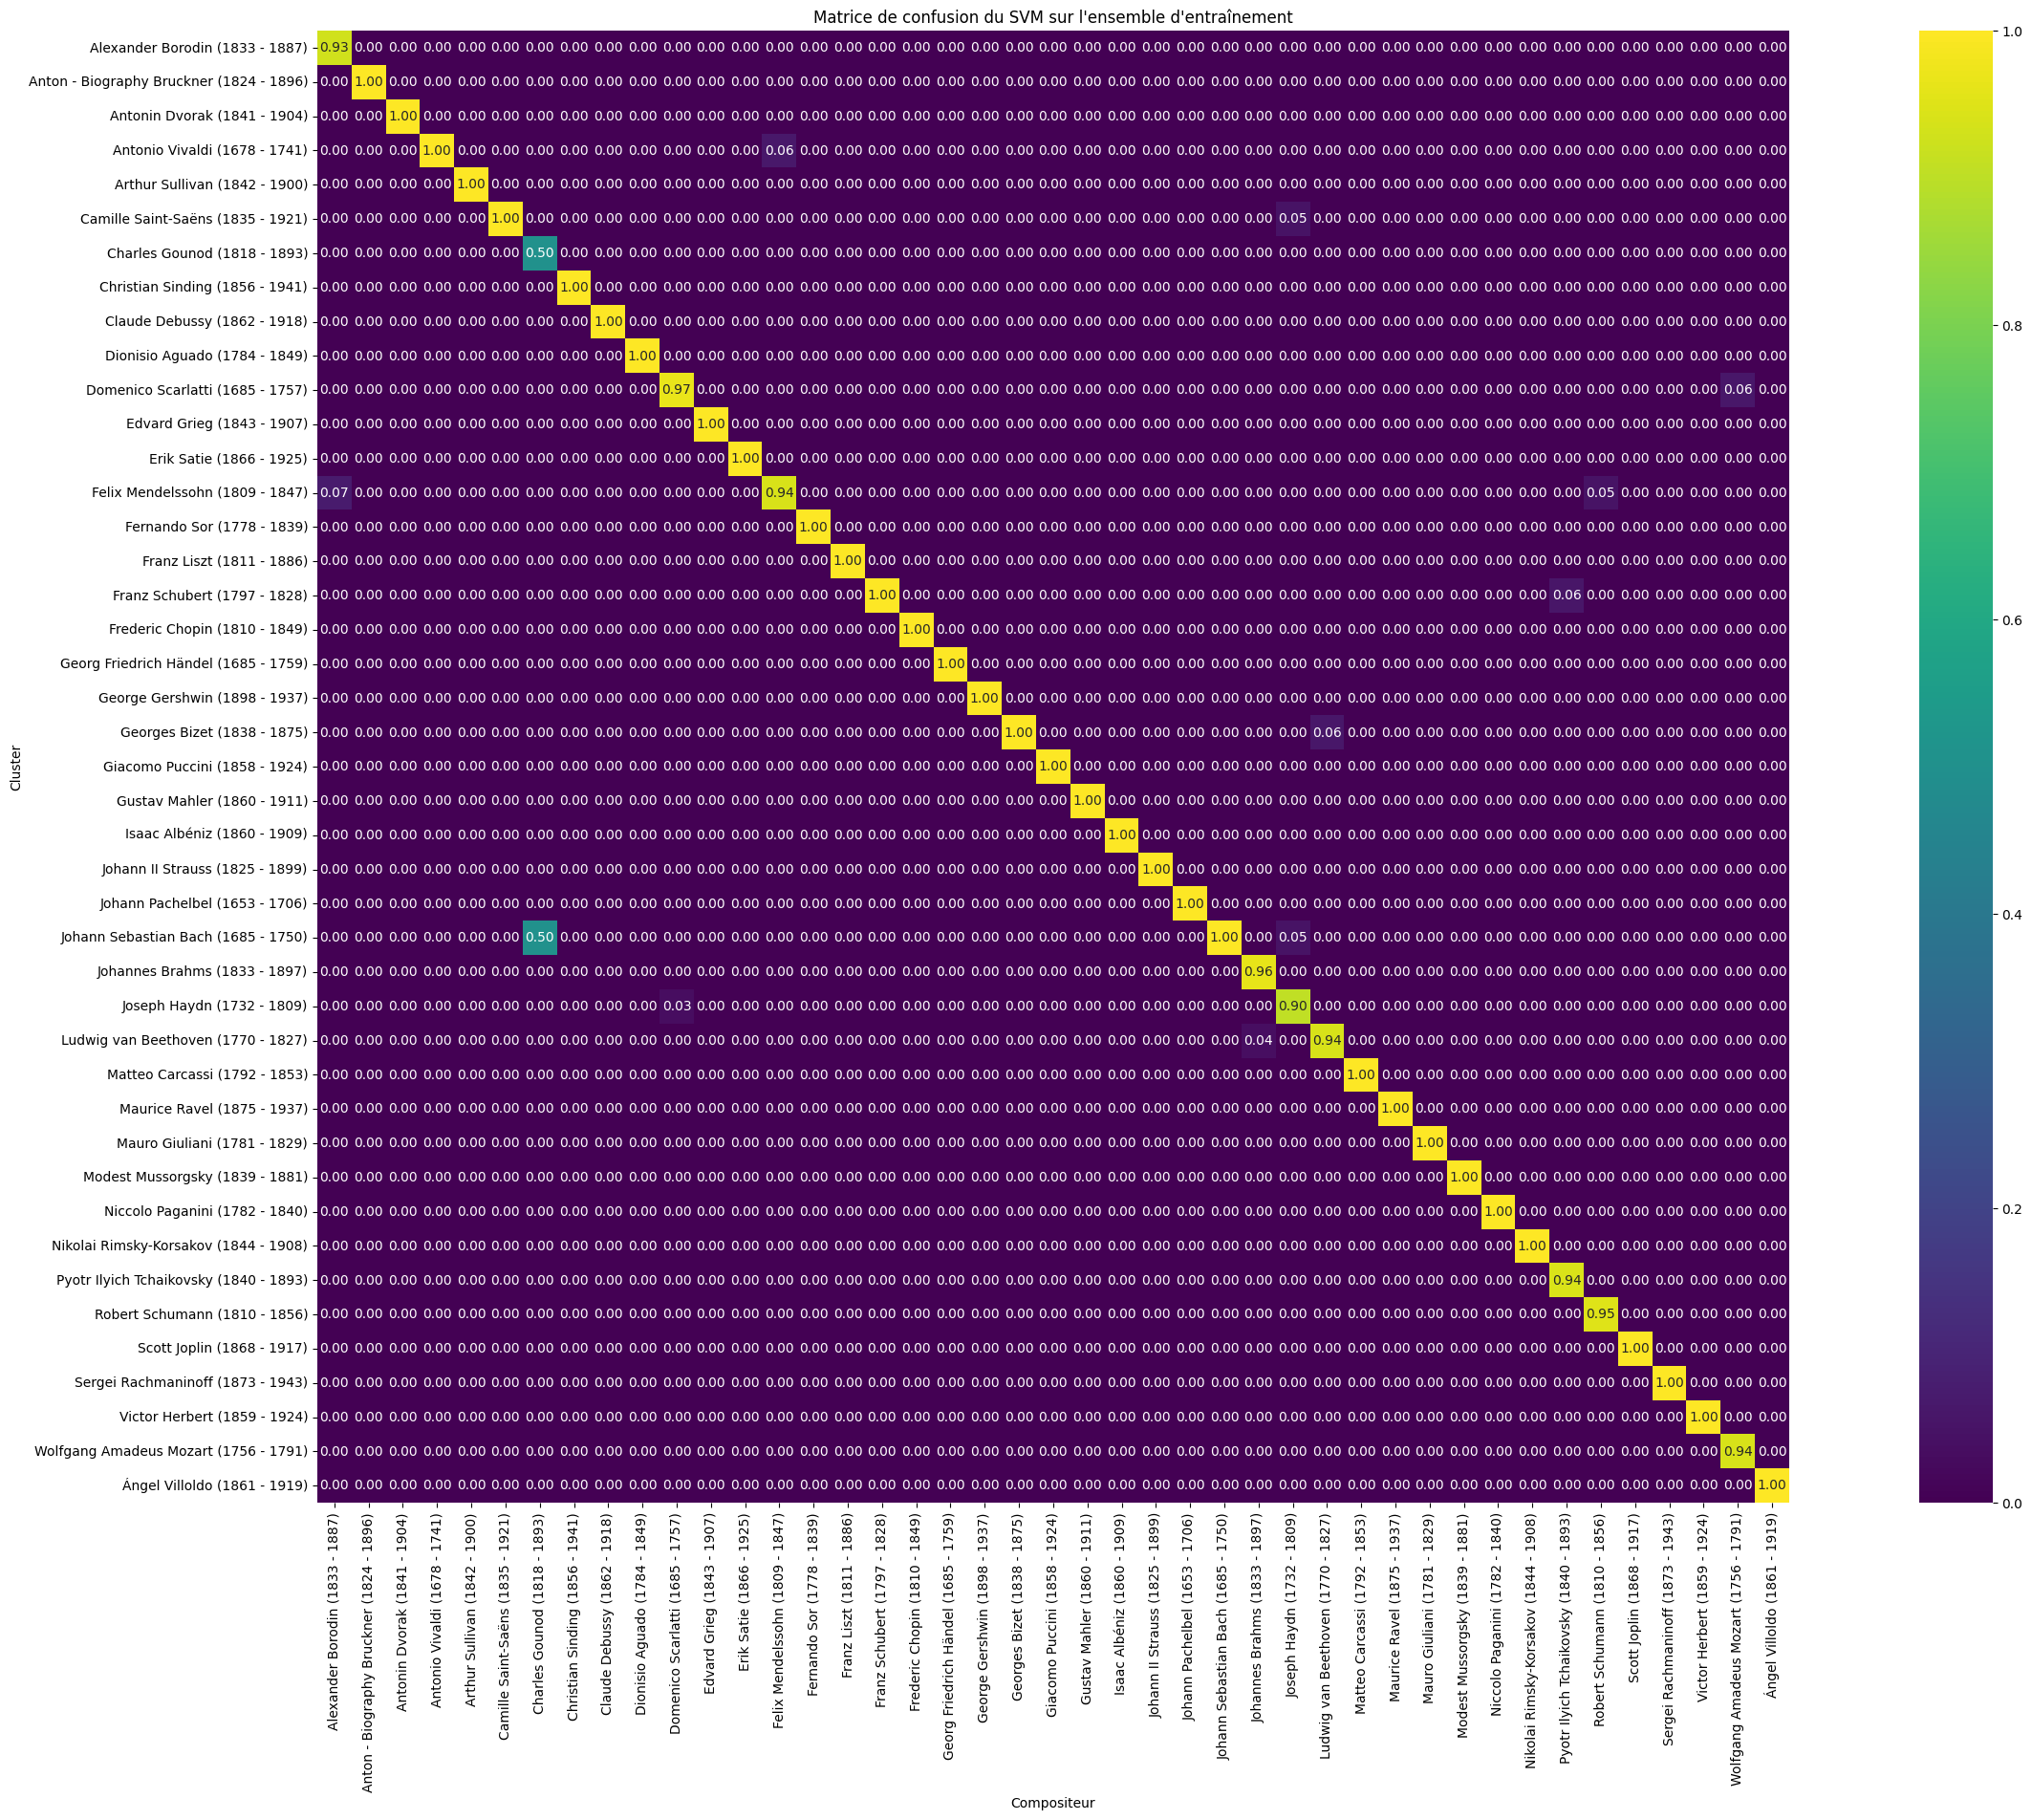

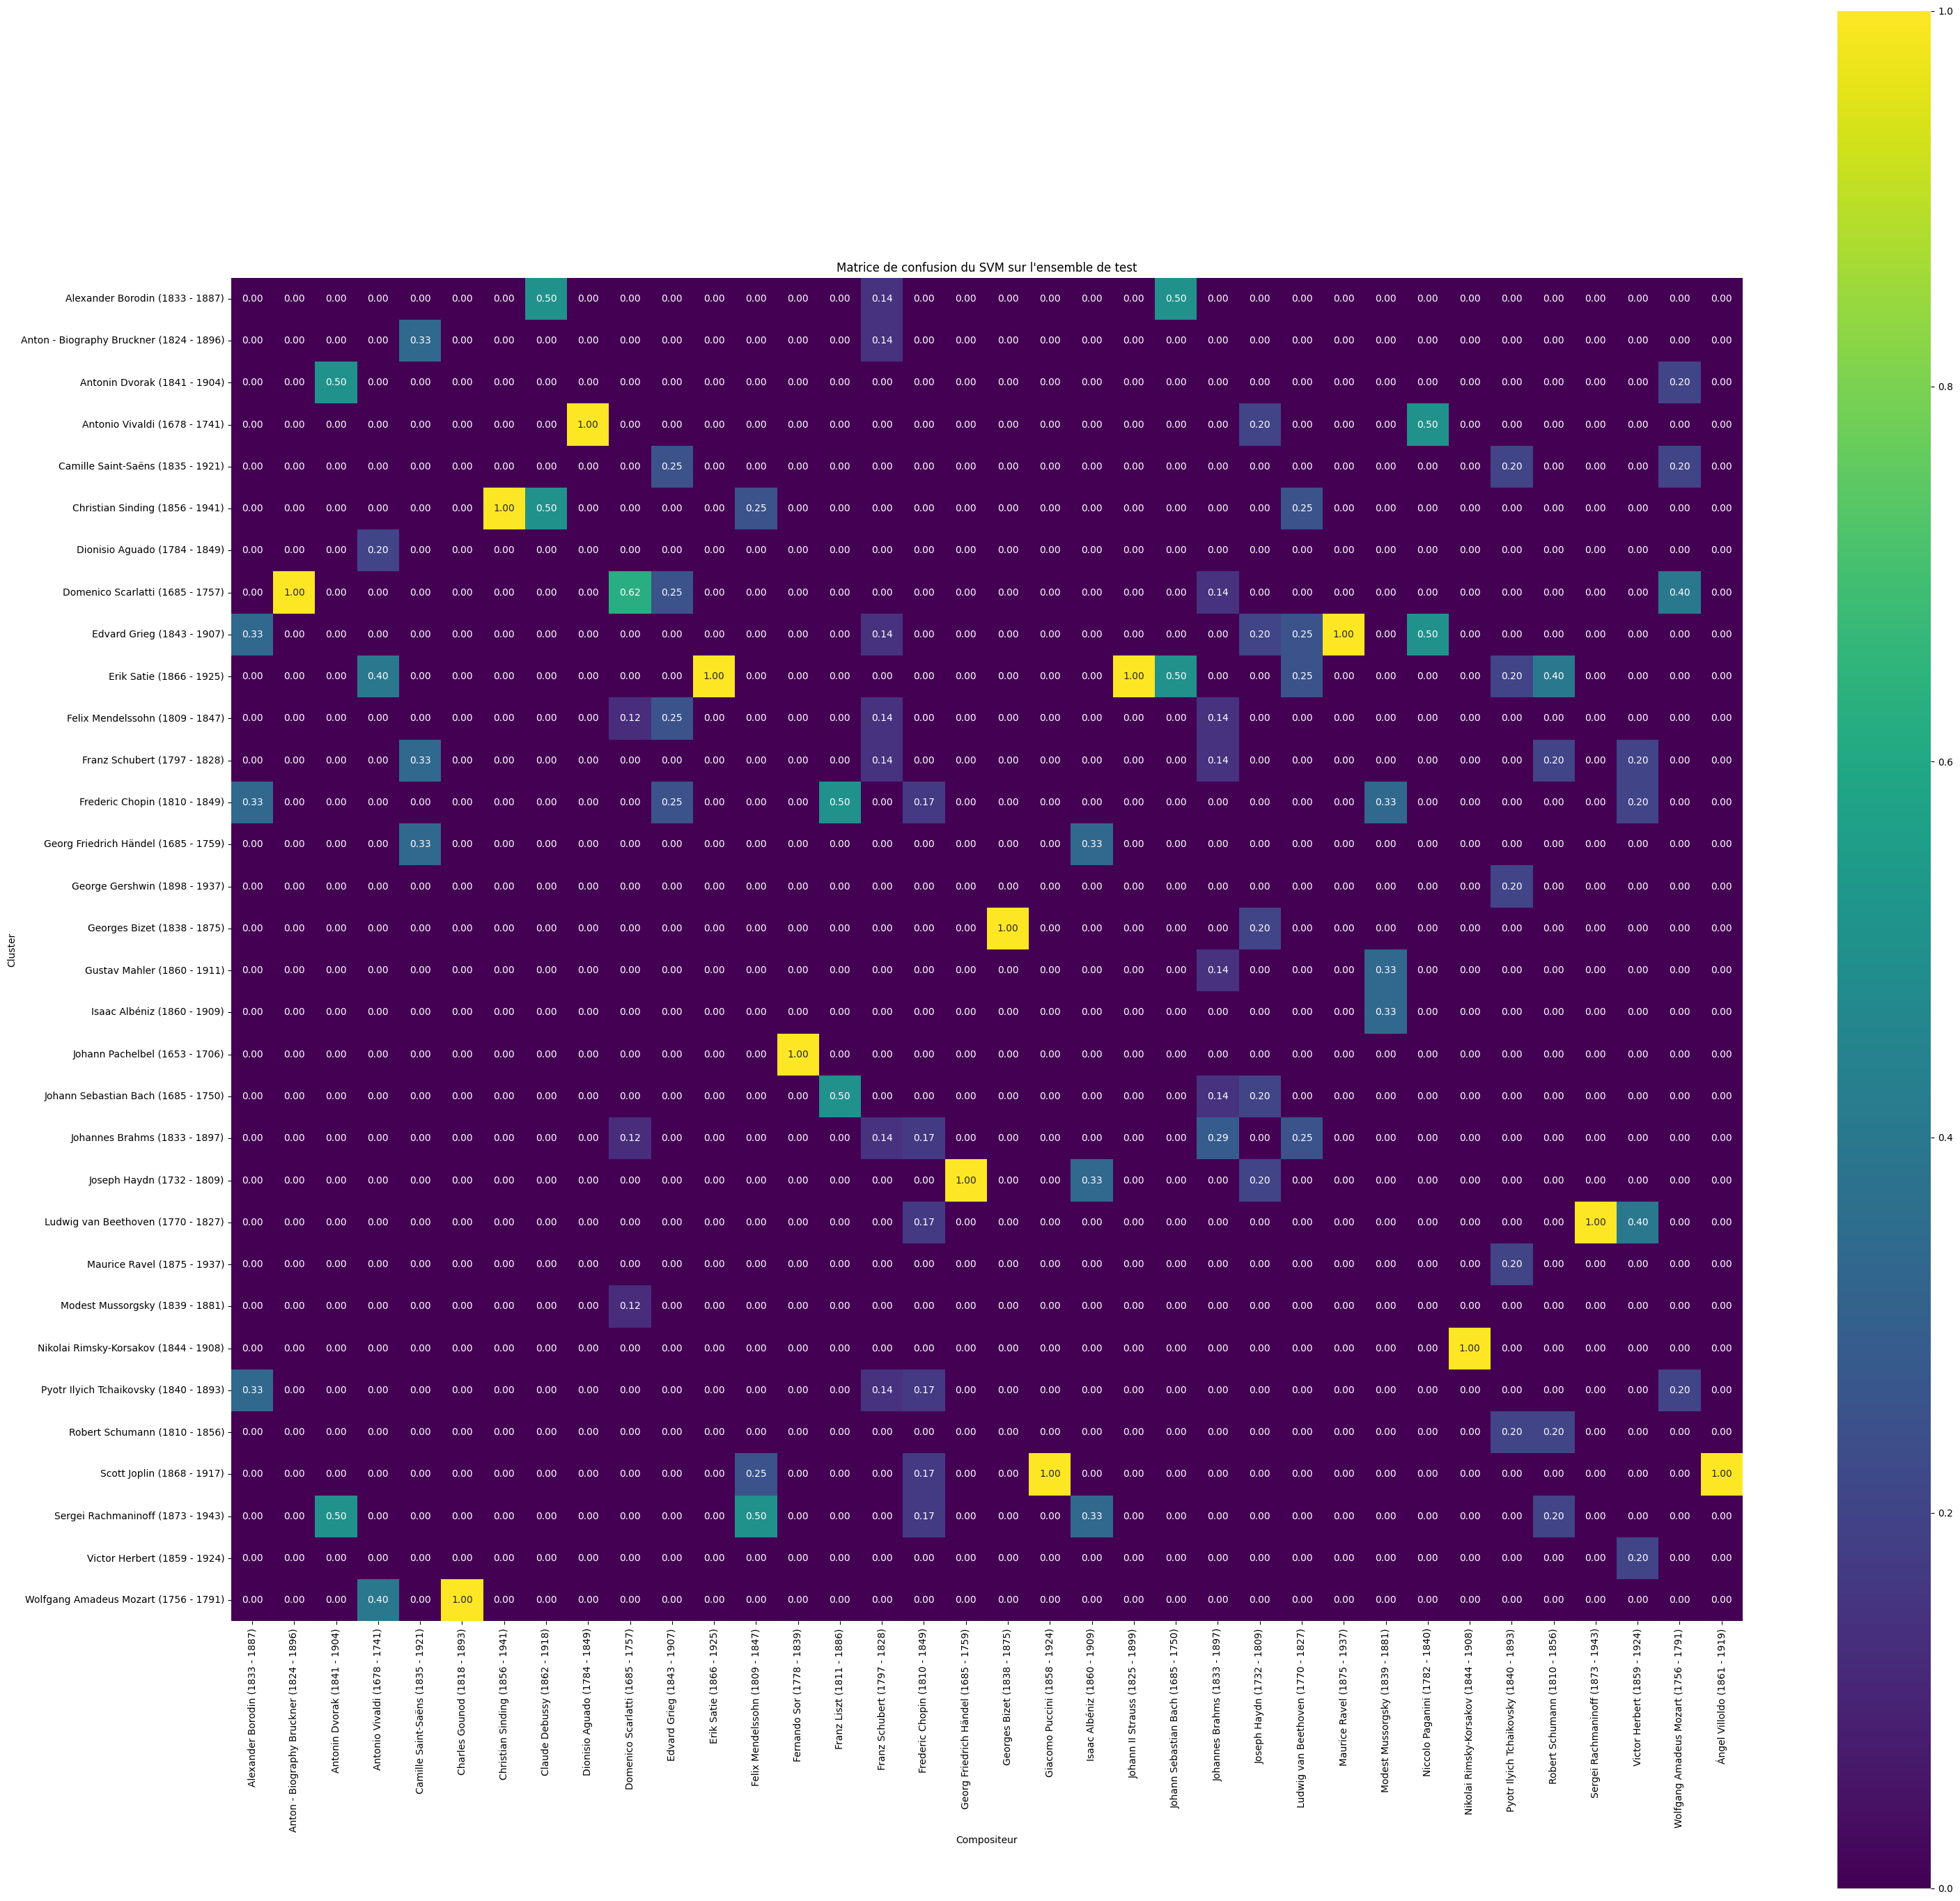

In [38]:
df_cm = pd.crosstab(y_train_pred, y_train)
df_cm = df_cm.div(df_cm.sum(axis=0), axis=1)
plt.figure(figsize=(35, 20))
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap='viridis', square = True)
plt.xlabel('Compositeur')
plt.ylabel('Cluster')
plt.title("Matrice de confusion du SVM sur l'ensemble d'entraînement")
plt.show()

df_cm = pd.crosstab(y_test_pred, y_test)
df_cm = df_cm.div(df_cm.sum(axis=0), axis=1)
plt.figure(figsize=(35, 35))
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap='viridis', square = True)
plt.xlabel('Compositeur')
plt.ylabel('Cluster')
plt.title("Matrice de confusion du SVM sur l'ensemble de test")
plt.show()

## Test de la LDA

In [46]:
from sklearn.cluster import KMeans

dim_pca = 20

with open("data_classicalsde_N=5.pkl", "rb") as f:
    dico_cross_era_sup, grouping_dict, compo_dict = pickle.load(f)

li_outliers = ['Rossini', 'Necke', 'Mascagni', "Traditional"]
X = []
etiquettes = []
y = []
groupe = []
for file, histograms in dico_cross_era_sup.items():
    composer = compo_dict[file]
    if any(outlier in composer for outlier in li_outliers):
        continue
    else:
        etiquettes.append(file.split("\\")[-2] + '\\' + file.split('\\')[-1])
        matrice = np.vstack(histograms)
        X.append(matrice.flatten())
        y.append(composer)
        groupe.append(grouping_dict[file][1])

X = np.array(X)
y = np.array(y)
periodes = np.array(groupe)
morceaux = np.array(etiquettes)

compteur = Counter(y)
indices_a_garder = [i for i, label in enumerate(y) if compteur[label] > 1 and 'Traditional' not in label]

X = X[indices_a_garder]
y = y[indices_a_garder]

X_scaled = StandardScaler().fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

reducer = LDA(n_components=dim_pca)
reducer.fit(X_train, y_train)
X_train_pca = reducer.transform(X_train)
X_test_pca = reducer.transform(X_test)

print("PCA faite")

n_clusters = len(np.unique(y))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X_train_pca)
y_train_pred = kmeans.predict(X_train_pca)
y_test_pred = kmeans.predict(X_test_pca)

print("k-means entraîné")

lda = LDA(n_components=3)
X_train_lda = lda.fit_transform(X_train_pca, y_train)
X_test_lda = lda.transform(X_test_pca)

print("LDA faite")

df_visu = pd.DataFrame(X_test_lda, columns=['LD1', 'LD2', 'LD3'])
df_visu['composer'] = y_test
df_visu['pred'] = y_test_pred

fig = px.scatter_3d(
    df_visu,
    x='LD1', y='LD2', z='LD3',
    color='composer',
    symbol='pred',
    title="Résultats du SVM sur l'ensemble de test"
)
buttons = [
    dict(label='Tout masquer',
        method='restyle',
        args=['visible', ['legendonly'] * len(fig.data)]),
    
    dict(label='Tout afficher',
        method='restyle',
        args=['visible', [True] * len(fig.data)])
]

fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=True, buttons=buttons)]
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.show(renderer='browser')

PCA faite
k-means entraîné
LDA faite


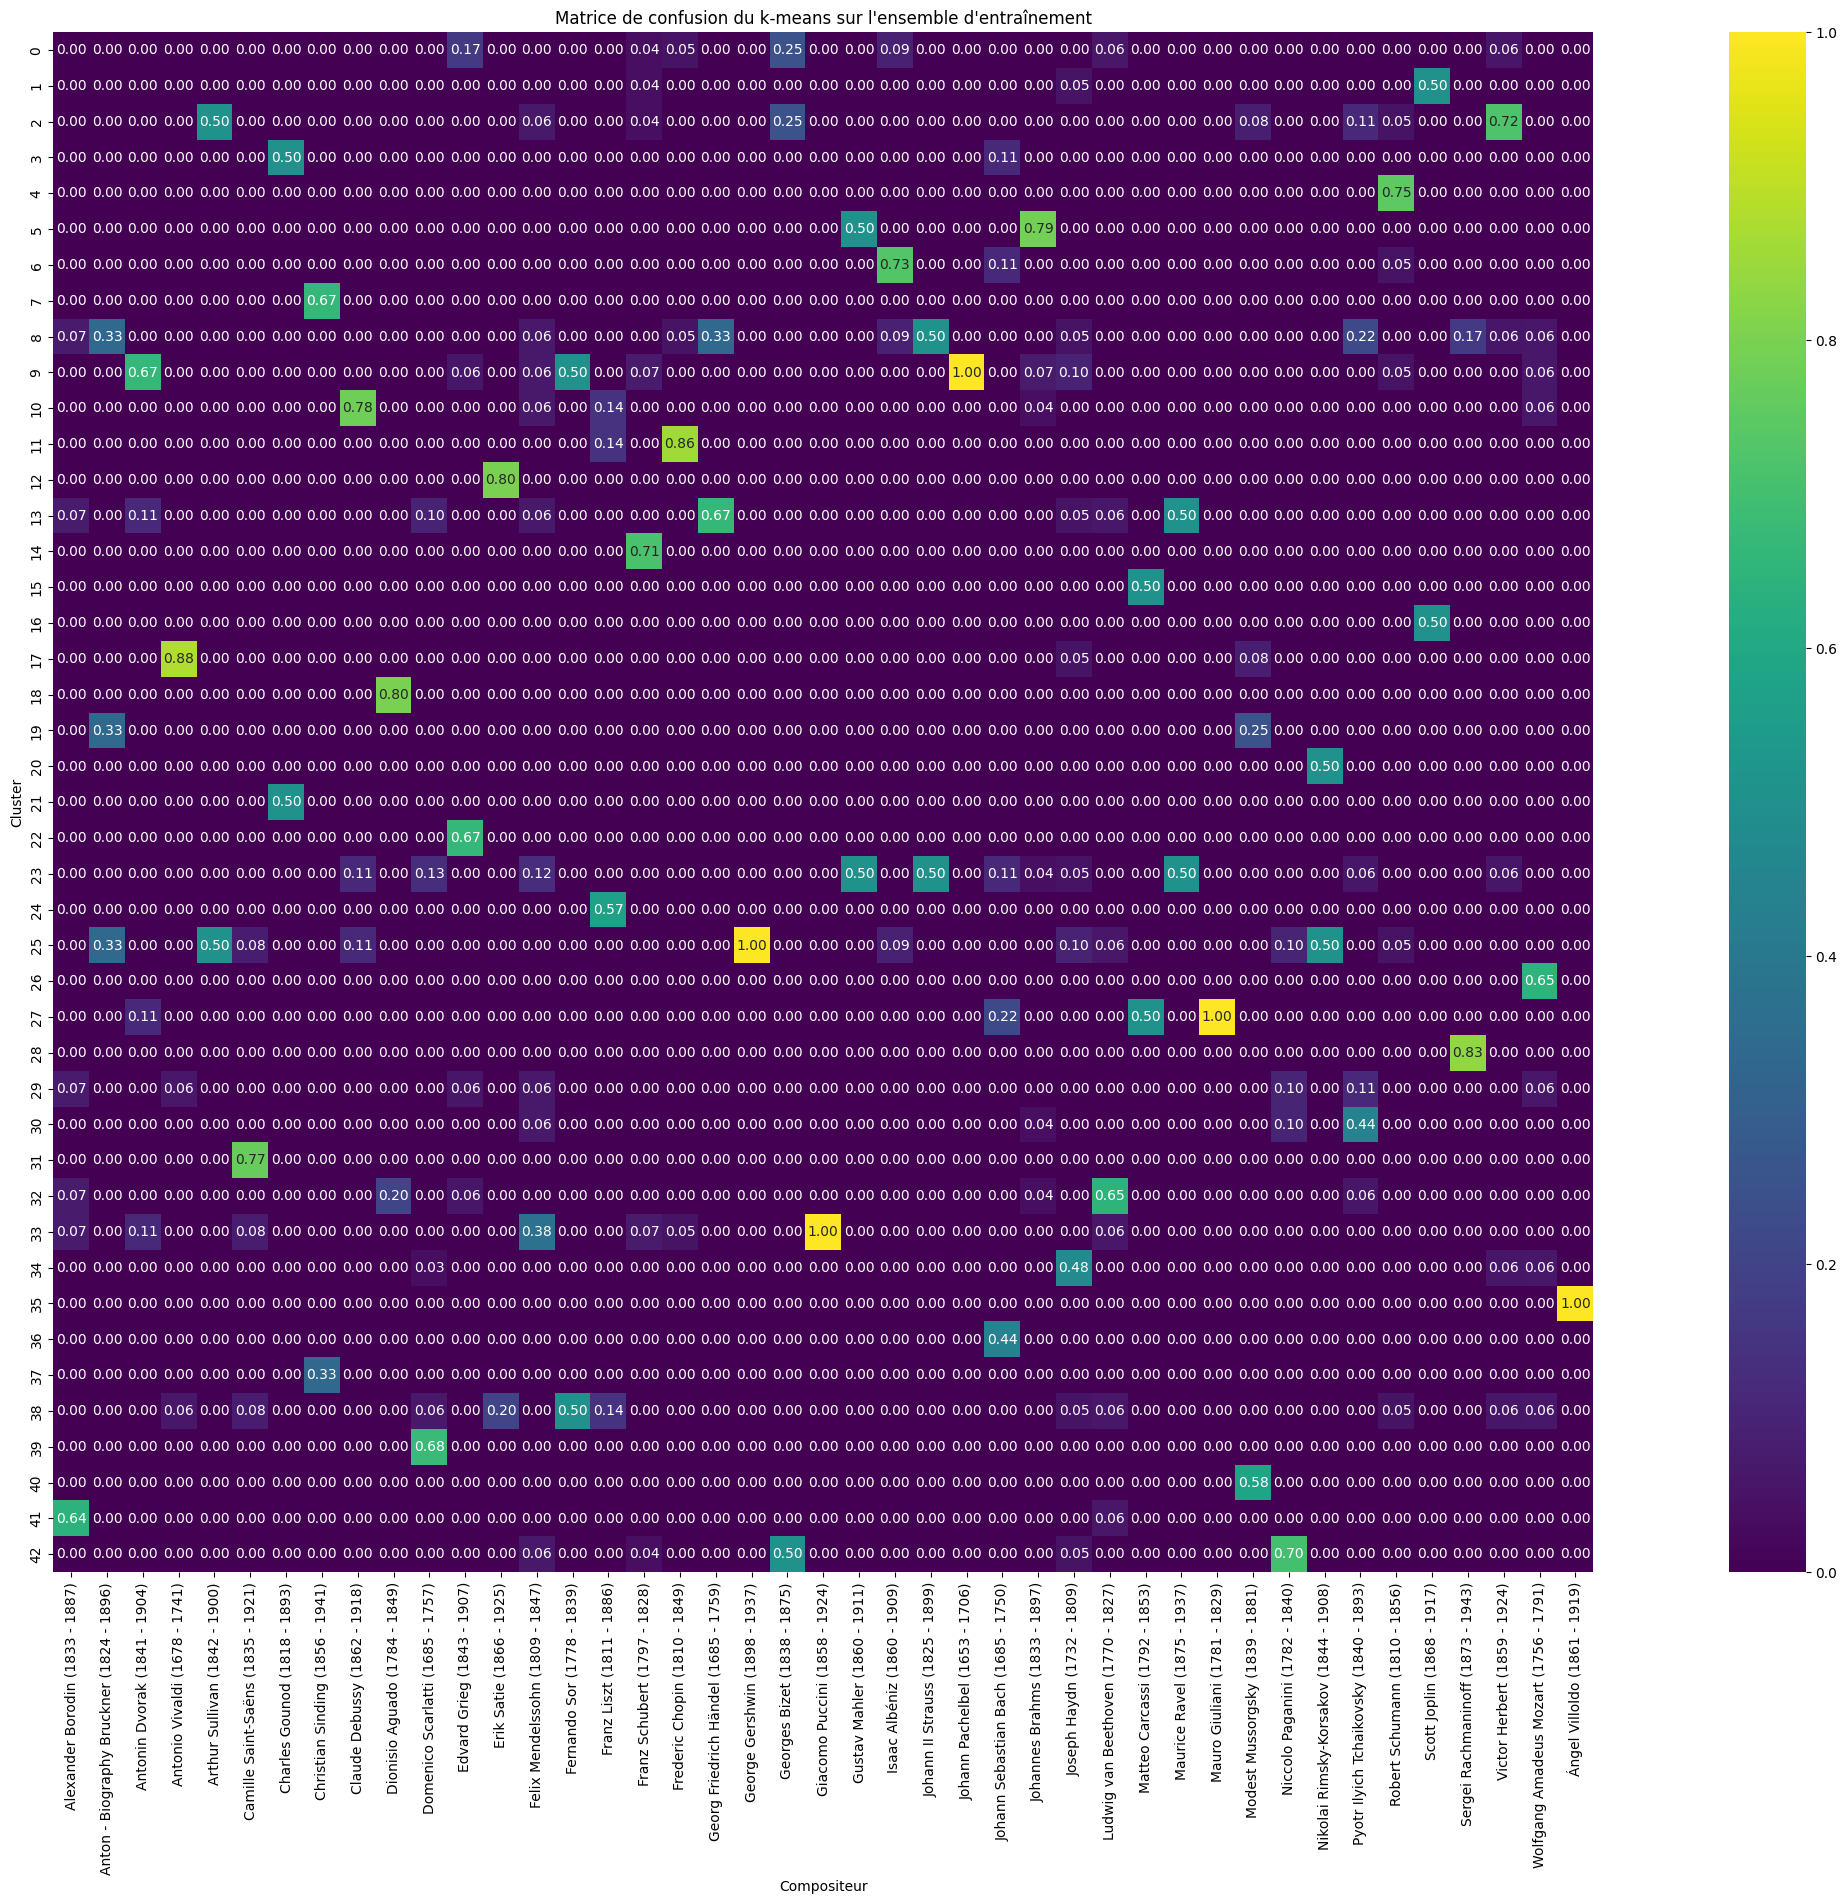

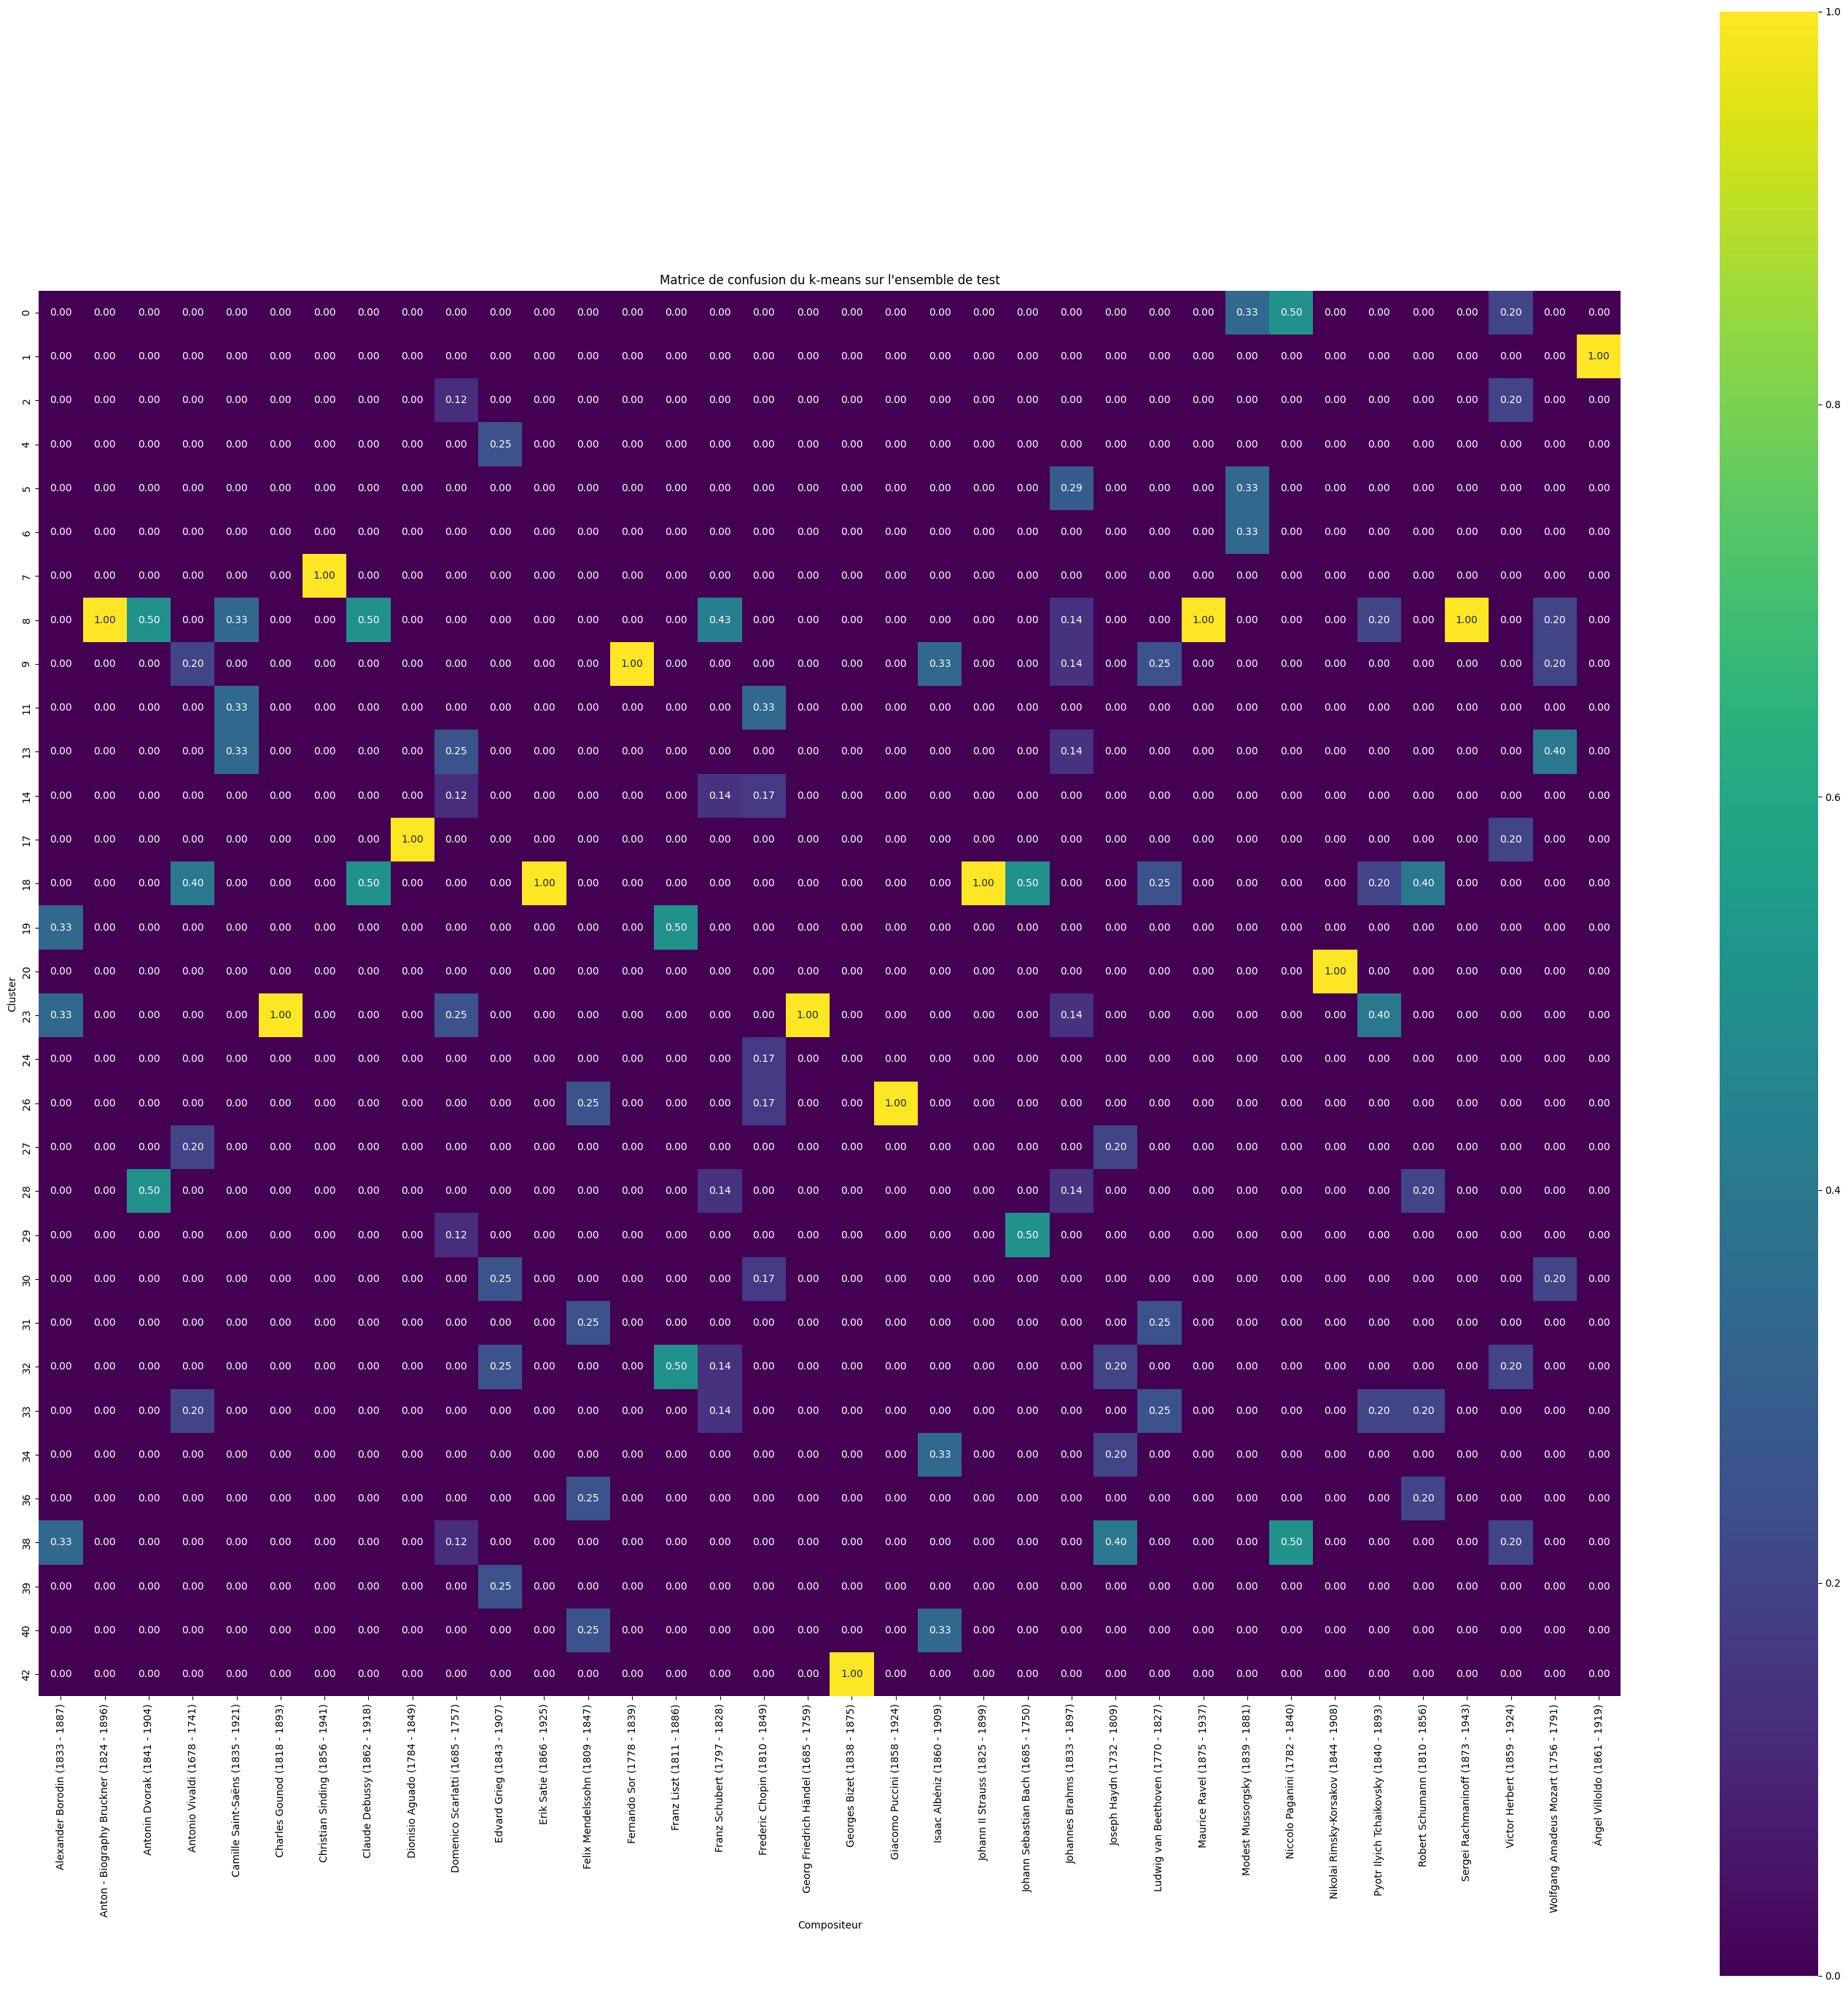

In [48]:
df_cm = pd.crosstab(y_train_pred, y_train)
df_cm = df_cm.div(df_cm.sum(axis=0), axis=1)
plt.figure(figsize=(35, 20))
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap='viridis', square = True)
plt.xlabel('Compositeur')
plt.ylabel('Cluster')
plt.title("Matrice de confusion du k-means sur l'ensemble d'entraînement")
plt.show()

df_cm = pd.crosstab(y_test_pred, y_test)
df_cm = df_cm.div(df_cm.sum(axis=0), axis=1)
plt.figure(figsize=(35, 35))
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap='viridis', square = True)
plt.xlabel('Compositeur')
plt.ylabel('Cluster')
plt.title("Matrice de confusion du k-means sur l'ensemble de test")
plt.show()